In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpateches
import pickle
import json
from pathlib import Path

#carrega o dataset

df = pd.read_csv("../data/processed/safras_mg.csv")

#carrega o modelo salvo

with open("../outputs/modelo_agro_predict.pkl", "rb") as f:
    modelo = pickle.load(f)

#carrega as métricas

with open("../outputs/metricas.json", "r") as f:
    metricas = json.load(f)

#recria as features
X = df[["chuva_total", "temp_media", "temp_min_media",
        "et0_total", "dias_sem_chuva", "tendencia"]]

#gera previsão para todas as safras
df["previsto"] = modelo.predict(X).round(1)
df["erro"] = (df["previsto"] - df["produtividade_sc_ha"]).round(1)
margem = df["erro"].std()

print("Tudo pronto! Vamos visualizar os resultados...")
print(f"R²: {metricas['r2']} | MAE: {metricas['mae']} sc/ha | Margem de erro (std): ±{margem:.1f} sc/ha")

Tudo pronto! Vamos visualizar os resultados...
R²: 0.716 | MAE: 5.18 sc/ha | Margem de erro (std): ±4.3 sc/ha


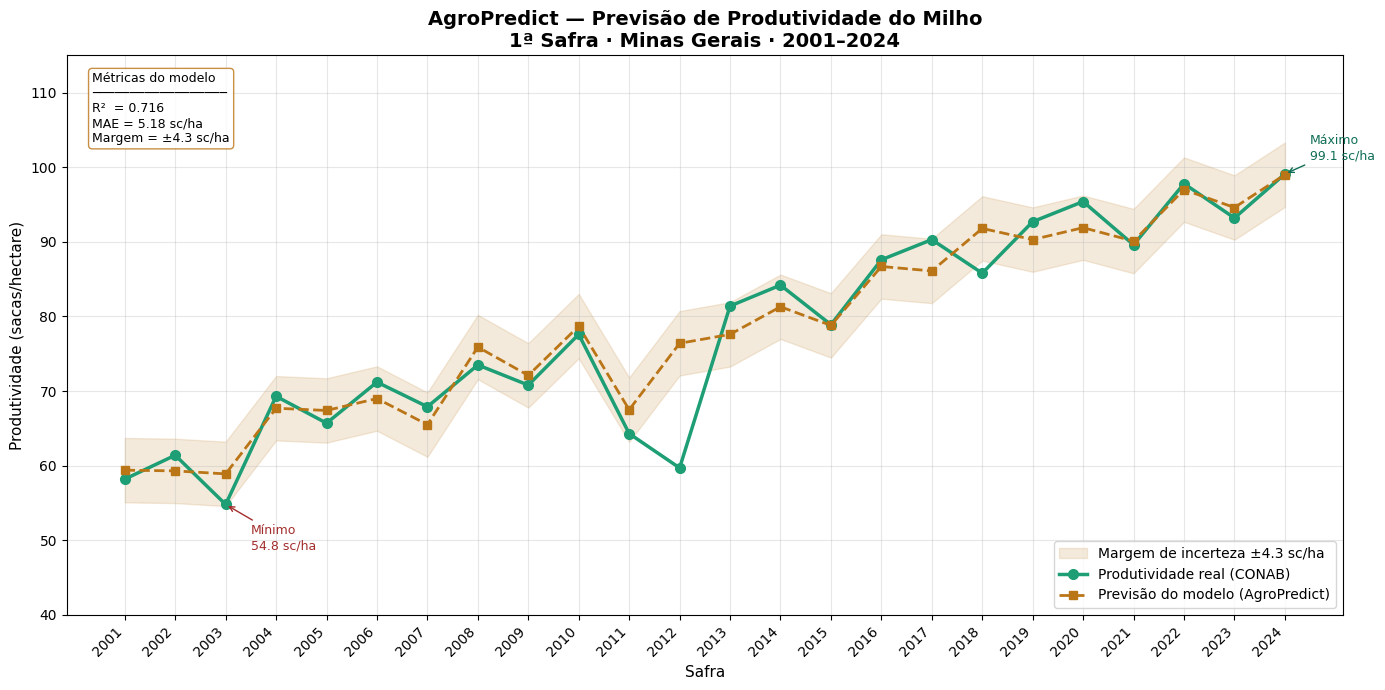

Gráfico final salvo em outputs/agropredict_final.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

# ── faixa de incerteza ──
ax.fill_between(df["safra"],
                df["previsto"] - margem,
                df["previsto"] + margem,
                color="#BA7517", alpha=0.15,
                label=f"Margem de incerteza ±{margem:.1f} sc/ha")

# ── linha real ──
ax.plot(df["safra"], df["produtividade_sc_ha"],
        "o-", color="#1D9E75", linewidth=2.5,
        markersize=7, label="Produtividade real (CONAB)")

# ── linha prevista ──
ax.plot(df["safra"], df["previsto"],
        "s--", color="#BA7517", linewidth=2,
        markersize=6, label="Previsão do modelo (AgroPredict)")

# ── destaca anos extremos ──
ano_min = df.loc[df["produtividade_sc_ha"].idxmin(), "safra"]
ano_max = df.loc[df["produtividade_sc_ha"].idxmax(), "safra"]
val_min = df["produtividade_sc_ha"].min()
val_max = df["produtividade_sc_ha"].max()

ax.annotate(f"Mínimo\n{val_min} sc/ha",
            xy=(ano_min, val_min),
            xytext=(ano_min + 0.5, val_min - 6),
            fontsize=9, color="#A32D2D",
            arrowprops=dict(arrowstyle="->", color="#A32D2D"))

ax.annotate(f"Máximo\n{val_max} sc/ha",
            xy=(ano_max, val_max),
            xytext=(ano_max + 0.5, val_max + 2),
            fontsize=9, color="#0F6E56",
            arrowprops=dict(arrowstyle="->", color="#0F6E56"))

# ── caixa de métricas ──
texto_metricas = (
    f"Métricas do modelo\n"
    f"──────────────────\n"
    f"R²  = {metricas['r2']}\n"
    f"MAE = {metricas['mae']} sc/ha\n"
    f"Margem = ±{margem:.1f} sc/ha"
)
ax.text(0.02, 0.97, texto_metricas,
        transform=ax.transAxes,
        fontsize=9, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white",
                  edgecolor="#BA7517", alpha=0.8))

# ── formatação ──
ax.set_title("AgroPredict — Previsão de Produtividade do Milho\n"
             "1ª Safra · Minas Gerais · 2001–2024",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Safra", fontsize=11)
ax.set_ylabel("Produtividade (sacas/hectare)", fontsize=11)
ax.set_xticks(df["safra"])
ax.set_xticklabels(df["safra"], rotation=45, ha="right")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(40, 115)

plt.tight_layout()
plt.savefig("../outputs/agropredict_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico final salvo em outputs/agropredict_final.png")